# Regression Analysis

Given two distinct data points, we can always draw a straight line passing through both. However, when we have three non-collinear points, no single straight line can pass through all three.

This raises an interesting question: **If a straight line cannot pass through every data point, can we find one that best represents them?**

This is where regression comes in. Through regression analysis, we attempt to find a line (or a curve) that best captures the overall relationship between two variables, even when the data points do not lie perfectly on a straight line (or a curve).

::: {.callout-note}
## What’s in a name!
In the 1880s, Francis Galton studied the relationship between parents’ and children’s heights. He found that unusually tall parents tended to have children whose heights were less extreme, and similarly for unusually short parents.
He called this **regression toward mediocrity** (where *mediocrity* meant the population mean).

Today, **regression** refers to methods for modeling the relationship between variables, even when there is no particular phenomenon of values moving toward the mean.

:::


## Linear regression

When a set of data points does not lie perfectly on a straight line, we may still be able to identify an overall trend. Linear regression is a statistical method used to model this trend by fitting a straight line to the observed data points.

**How do we decide which straight line best represents the data?** There may be many possible lines passing through the general vicinity of the data points. To choose among them, we need a criterion for measuring how well a line fits the data. One widely used approach is the method of *least squares*, which selects the line that minimizes the sum of the squared differences between the observed values and the values predicted by the line.

### Line of best fit

To understand the concept of a line of best fit, look at the three graphs in @fig-ssr, each shows a different line drawn through the same set of data points. By looking at these lines, you might think that the middle one is the line of best fit. However, choosing the line of best fit is not simply about how many data points the line passes through. It is about how closely the line fits the data overall.

To measure how well a line fits the data, we use **residuals**. A residual is the difference between the actual value of a data point and the value predicted by the line. For each data point that does not lie on the line, we can draw a vertical line segment between the point and the line, as shown by the dashed red lines in the graphs. The length of this segment represents the absolute value of the residual.

To determine the line of best fit, we square each residual and add the squared values together. The line that gives the smallest **sum of squared residuals (SSR)** is called the **least-squares line of best fit**. Mathematically,

$\text{SSR} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$

Where, $y_i$ is the actual (observed) value of the $i$-th data point, $\hat{y}_i$ is the predicted value from the line of best fit, and $n$ is the total number of data points.


In [2]:
#| message: false
#| warning: false
#| echo: false
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


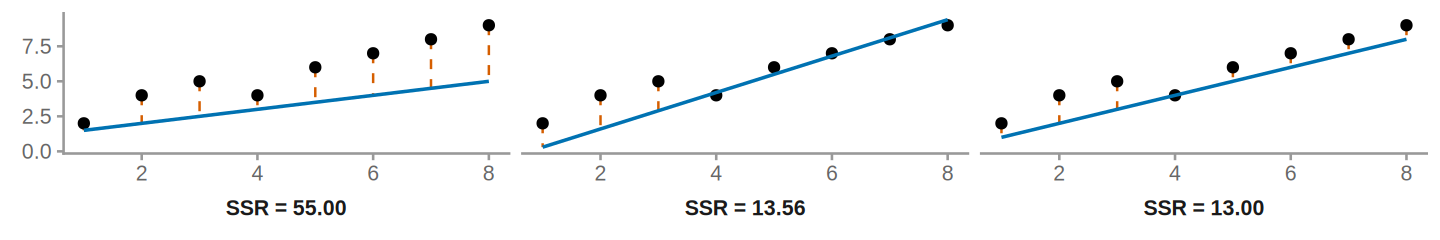

In [3]:
#| fig-cap: "Sum of squared residuals (SSR) for different lines given a set of data points."
#| label: fig-ssr
#| echo: false
options(repr.plot.width = 12, repr.plot.height = 2)

# Observed data
df <- data.frame(
  x = c(1, 2, 3, 4, 5, 6, 7, 8),
  y = c(2, 4, 5, 4, 6, 7, 8, 9)
)

# Three candidate lines
lines <- data.frame(
  Line = c("Line 1", "Line 2", "Line 3"),
  intercept = c(1, -1, 0),
  slope = c(0.5, 1.3, 1)
)

# Calculate predictions and sum of squared residuals
results <- lines |>
  rowwise() |>
  mutate(
    details = list(
      data.frame(
        x = df$x,
        observed = df$y,
        predicted = intercept + slope * df$x
      )
    ),
    SSR = sum((df$y - (intercept + slope * df$x))^2)
  ) |>
  ungroup() |>
  mutate(
    facet_label = paste0("SSR = ", sprintf("%.2f", SSR)),
    facet_label = factor(facet_label, levels = facet_label)
  )

# Prepare data for plotting
plot_df <- results |>
  select(Line, intercept, slope, details, facet_label) |>
  unnest(details) |>
  mutate(
    residual = observed - predicted,
    squared_residual = residual^2
  )

# Print SSR values
#results |>
#  select(Line, intercept, slope, SSR) #|>
#  print()

# Plot residuals for all three candidate lines
ggplot(plot_df, aes(x = x)) +
  geom_segment(
    aes(
      xend = x,
      y = observed,
      yend = predicted
    ),
    color = "#D55E00",
    linetype = "dashed",
    linewidth = 0.7
  ) +
  geom_point(
    aes(y = observed),
    color = "black",
    size = 2.5
  ) +
  geom_line(
    aes(y = predicted, group = Line),
    color = "#0072B2",
    linewidth = 1
  ) +
  facet_wrap(
    ~ facet_label,
    nrow = 1,
    strip.position = "bottom"
  ) +
  labs(
    x = NULL,
    y = NULL
  ) +
  theme_classic(base_size = 16) +
  theme(
    plot.title = element_text(face = "bold"),
    strip.background = element_blank(),
    strip.text = element_text(face = "bold"),
    strip.placement = "outside",
    axis.line = element_line(color = "grey60"),
    axis.ticks = element_line(color = "grey60"),
    axis.text = element_text(color = "grey40")
  )


::: {.callout-tip collapse="true"}
## What happens when we change the exponent in the SSR formula?
A [research article](https://www.sciencepublishinggroup.com/article/10.11648/j.ajtas.20241306.12) by Hoffman and Montesinos-Yufa (2024), compares ordinary least squares (p=2) with regression models using different powers, from p=1.2 to p=2.8. It uses simulated data with normal, uniform, exponential and Cauchy error distributions. The authors show that changing p changes the estimated regression coefficients, and that the effect depends on the distribution of the errors.

:::


### The Palmer Pengiuns dataset



In [4]:
#| message: false
#| warning: false
install.packages("palmerpenguins")
library(palmerpenguins)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw




In [5]:
head(penguins)

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,39.1,18.7,181,3750,male,2007
Adelie,Torgersen,39.5,17.4,186,3800,female,2007
Adelie,Torgersen,40.3,18.0,195,3250,female,2007
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,36.7,19.3,193,3450,female,2007
Adelie,Torgersen,39.3,20.6,190,3650,male,2007


In [4]:
dim(penguins)

[1] 344   8

In [ ]:
#| include: false

install.packages("GGally")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘ggstats’




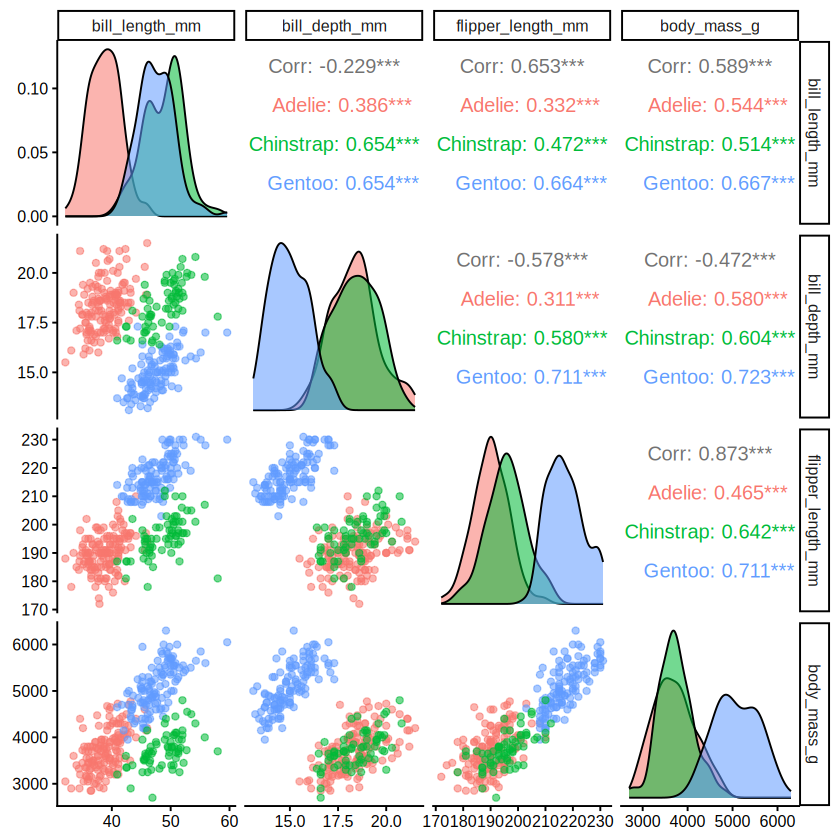

In [ ]:
#| include: false

library(GGally)
penguins_clean <- na.omit(penguins)

ggpairs(
  penguins_clean,
  columns = 3:6,             # Select specific numeric columns (flipper length, bill length, etc.)
  aes(color = species, alpha = 0.7)
) +
  theme_classic(base_size = 12)

In [7]:
#| include: false
glimpse(penguins)

Rows: 344
Columns: 8
$ species           <fct> Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adel…
$ island            <fct> Torgersen, Torgersen, Torgersen, Torgersen, Torgerse…
$ bill_length_mm    <dbl> 39.1, 39.5, 40.3, NA, 36.7, 39.3, 38.9, 39.2, 34.1, …
$ bill_depth_mm     <dbl> 18.7, 17.4, 18.0, NA, 19.3, 20.6, 17.8, 19.6, 18.1, …
$ flipper_length_mm <int> 181, 186, 195, NA, 193, 190, 181, 195, 193, 190, 186…
$ body_mass_g       <int> 3750, 3800, 3250, NA, 3450, 3650, 3625, 4675, 3475, …
$ sex               <fct> male, female, female, NA, female, male, female, male…
$ year              <int> 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007…


In [ ]:
#| include: false
# penguins_raw has additional columns than penguins
tail(penguins_raw)

studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
PAL0910,63,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N98A1,Yes,2009-11-19,45.7,17.0,195,3650,FEMALE,9.26715,-24.31912,NA
PAL0910,64,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N98A2,Yes,2009-11-19,55.8,19.8,207,4000,MALE,9.70465,-24.53494,NA
PAL0910,65,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N99A1,No,2009-11-21,43.5,18.1,202,3400,FEMALE,9.37608,-24.40753,Nest never observed with full clutch.
PAL0910,66,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N99A2,No,2009-11-21,49.6,18.2,193,3775,MALE,9.46180,-24.70615,Nest never observed with full clutch.
PAL0910,67,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N100A1,Yes,2009-11-21,50.8,19.0,210,4100,MALE,9.98044,-24.68741,NA
PAL0910,68,Chinstrap penguin (Pygoscelis antarctica),Anvers,Dream,"Adult, 1 Egg Stage",N100A2,Yes,2009-11-21,50.2,18.7,198,3775,FEMALE,9.39305,-24.25255,NA


### Linear models

Base R provides the `lm()` function, which can be used to fit a linear regression model relating a response variable to one or more predictor variables.

Let's create a model that describes a relationship between a penguin's body mass and its flipper length. In this example, the body mass in the **dependent variable** (or response variable), while flipper is the **independent variable** (or predictor variable).

In [6]:
model <- lm(body_mass_g ~ flipper_length_mm, data = penguins)

We can check the model by printing the model, alternately we can use `coef()` function to get the coefficient for the model.

In [15]:
print(model)


Call:
lm(formula = body_mass_g ~ flipper_length_mm, data = penguins)

Coefficients:
      (Intercept)  flipper_length_mm  
         -5780.83              49.69  



Here, the linear model (or straight line) has an intercept of **-5780.83** and a slope of **49.69**. Based on this we can say that for every 1 mm increase in the penguin's flipper length, the model predicts an average increase of 49.69 grams in body mass. Hence, through this modeling, we have described a *linear* relationship between the two variables.

Note that the large negative intercept has little practical relevance here, since a flipper length of zero is far outside the range of the observed data.

We can write the equation for this model as follows:
$$ \text{body mass} = -5780.83 + 49.69\text{(flipper length)}$$

In [21]:
#| include: false
b <- coef(model)

eq <- sprintf(
  "$$\\widehat{\\text{body mass}} = %.2f %+.2f\\,\\text{flipper length}$$",
  b[1], b[2]
)
display_markdown(eq)

$$\widehat{\text{body mass}} = -5780.83 +49.69\,\text{flipper length}$$

Optionally, we can use the `quatiomatic` package to directly create an equation from the model as shown below.

In [18]:
#| include: false
install.packages("equatiomatic")
install.packages("IRdisplay")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘coda’, ‘furrr’, ‘broom.mixed’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [22]:
#| fold: true
#| code-summary: "Show Code"
#| results: asis
#| message: false
#| warning: false

library(equatiomatic)
library(IRdisplay)

eq1 <- extract_eq(model, use_coefs = TRUE)
eq_latex <- paste0(
  "$$\n",
  as.character(eq1),
  "\n$$"
)
display_markdown(eq_latex)

$$
\operatorname{\widehat{body\_mass\_g}} = -5780.83 + 49.69(\operatorname{flipper\_length\_mm})
$$

### Ploting a linear model

R provide several convinent ways to plot a linear model. Below are some of the options.
 - We can create a scatter plot for the data using the `plot()` function and then add a regression line using `abline()` function which accepts the model as an argument.
 - Using ggplot, we can add a layer `geom_abline()` and pass values for the `intercept` and `slope` keyword arguments.
 - The `geom_smooth()` function can be used to compute the linear model while plotting.

 @fig-linear-model shows the visualization of the linear regression analysis using the `geom_smooth()` function, using `method = "lm"`.

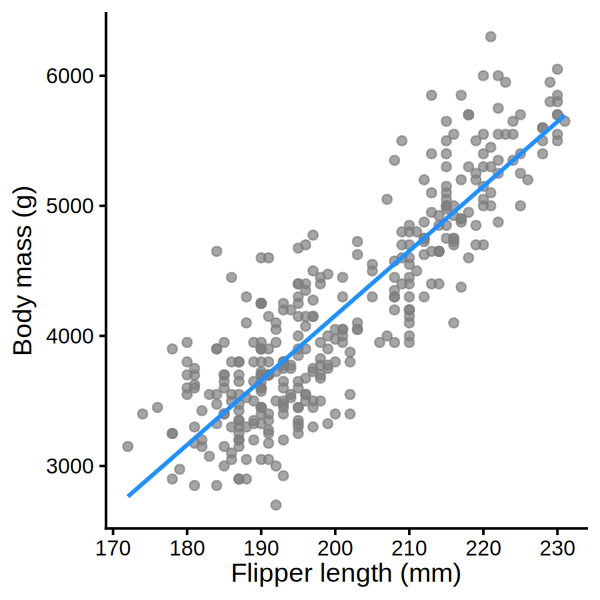

In [10]:
#| fig-cap: "Linear regression showing the line of best fit for predicting body mass from flipper length using the Palmer Penguins dataset."
#| label: fig-linear-model

options(repr.plot.width = 5, repr.plot.height = 5)

penguins |>
  # remove rows with missing values
  drop_na(body_mass_g, flipper_length_mm) |>

ggplot(aes(x = flipper_length_mm, y = body_mass_g)) +
  geom_point(color = "grey50", alpha = 0.7) +
  geom_smooth(
    method = "lm",
    formula = y ~ x, # vertical-axis variable predicted from horizontal-axis variable
    se = FALSE,
    color = "dodgerblue",
    linewidth = 1.2
  ) +
  labs(
    x = "Flipper length (mm)",
    y = "Body mass (g)"
    ) +
  theme_classic(base_size = 16)


### Predicting values

R's built-in function `predict()` can be used to predict the value for dependent variable given the value for independent variable, based on the linear model. For this we need to create a data frame having value for the independent variable. Note that the column name should match exactly to the variable name in model.

In [8]:
new_penguin <- data.frame(flipper_length_mm = 205)
predict(model, newdata = new_penguin)

1 
4404.71

Similarly, we can do prediction for multiple pengiuns as well.

In [10]:
new_penguins <- data.frame(flipper_length_mm = c(180, 200, 220))
data.frame(predict(model, newdata = new_penguins))

,predict.model..newdata...new_penguins.
,<dbl>
1,3162.571
2,4156.282
3,5149.993


We can also get confidence interval for the predicted values.

In [11]:
# Get predictions along with 95% prediction intervals
predict(model, newdata = new_penguins, interval = "prediction")

,fit,lwr,upr
1,3162.571,2383.398,3941.743
2,4156.282,3379.612,4932.951
3,5149.993,4371.240,5928.747


`geom_smooth()` using formula = 'y ~ x'


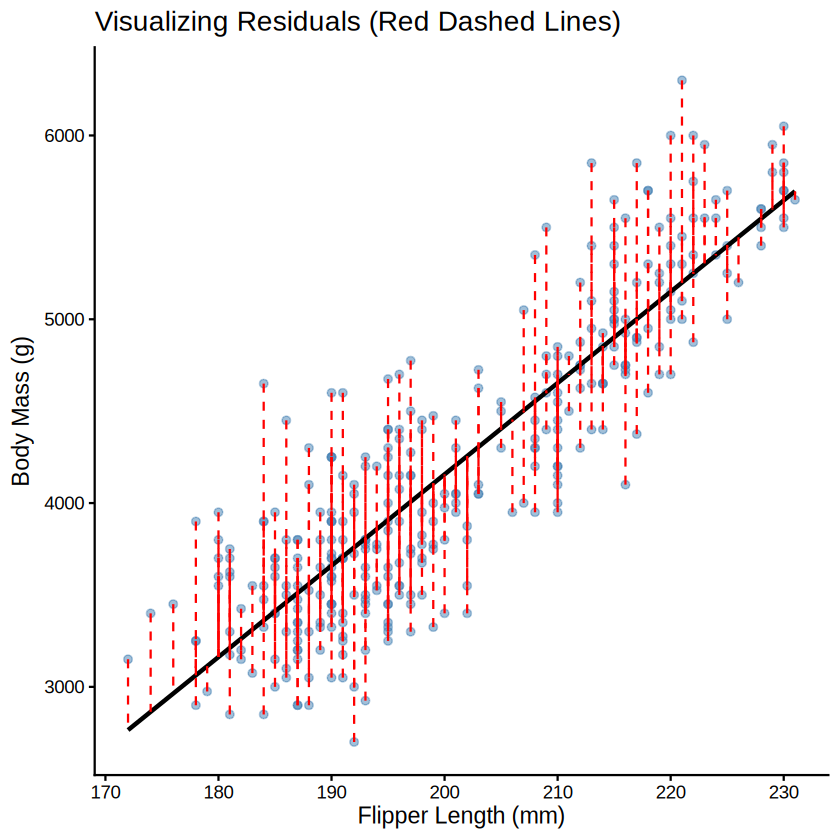

In [ ]:
#| include: false

df <- penguins %>% drop_na(body_mass_g, flipper_length_mm)

# Fit model and add predictions/residuals to the dataframe
df_aug <- df %>% mutate(
  predicted = predict(lm(body_mass_g ~ flipper_length_mm, data = .)),
  residual = body_mass_g - predicted
)

# Plot the regression line AND the residual "stems"
ggplot(df_aug, aes(x = flipper_length_mm, y = body_mass_g)) +
  geom_point(alpha = 0.5, color = "steelblue") +
  geom_smooth(method = "lm", se = FALSE, color = "black") +
  # This draws the vertical residual lines!
  geom_segment(aes(xend = flipper_length_mm, yend = predicted), color = "red", linetype = "dashed") +
  theme_classic(base_size = 14) +
  labs(title = "Visualizing Residuals (Red Dashed Lines)",
       x = "Flipper Length (mm)", y = "Body Mass (g)")

## Multiple regression

In [ ]:
#| message: false
#| warning: false
install.packages("performance")
install.packages("see")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bayestestR’, ‘insight’, ‘datawizard’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘correlation’, ‘effectsize’, ‘modelbased’, ‘patchwork’, ‘parameters’




In [ ]:
library(performance)
library(see)

In [ ]:
#| message: false
#| warning: false
# 1. Install the missing Linux system library
system("apt-get update && apt-get install -y libfftw3-dev")

# 2. Now install qqplotr again
install.packages("qqplotr")

# 3. Load it up
library(qqplotr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘qqconf’



Attaching package: ‘qqplotr’


The following objects are masked from ‘package:ggplot2’:

    stat_qq_line, StatQqLine




Ignoring unknown labels:
• size : ""


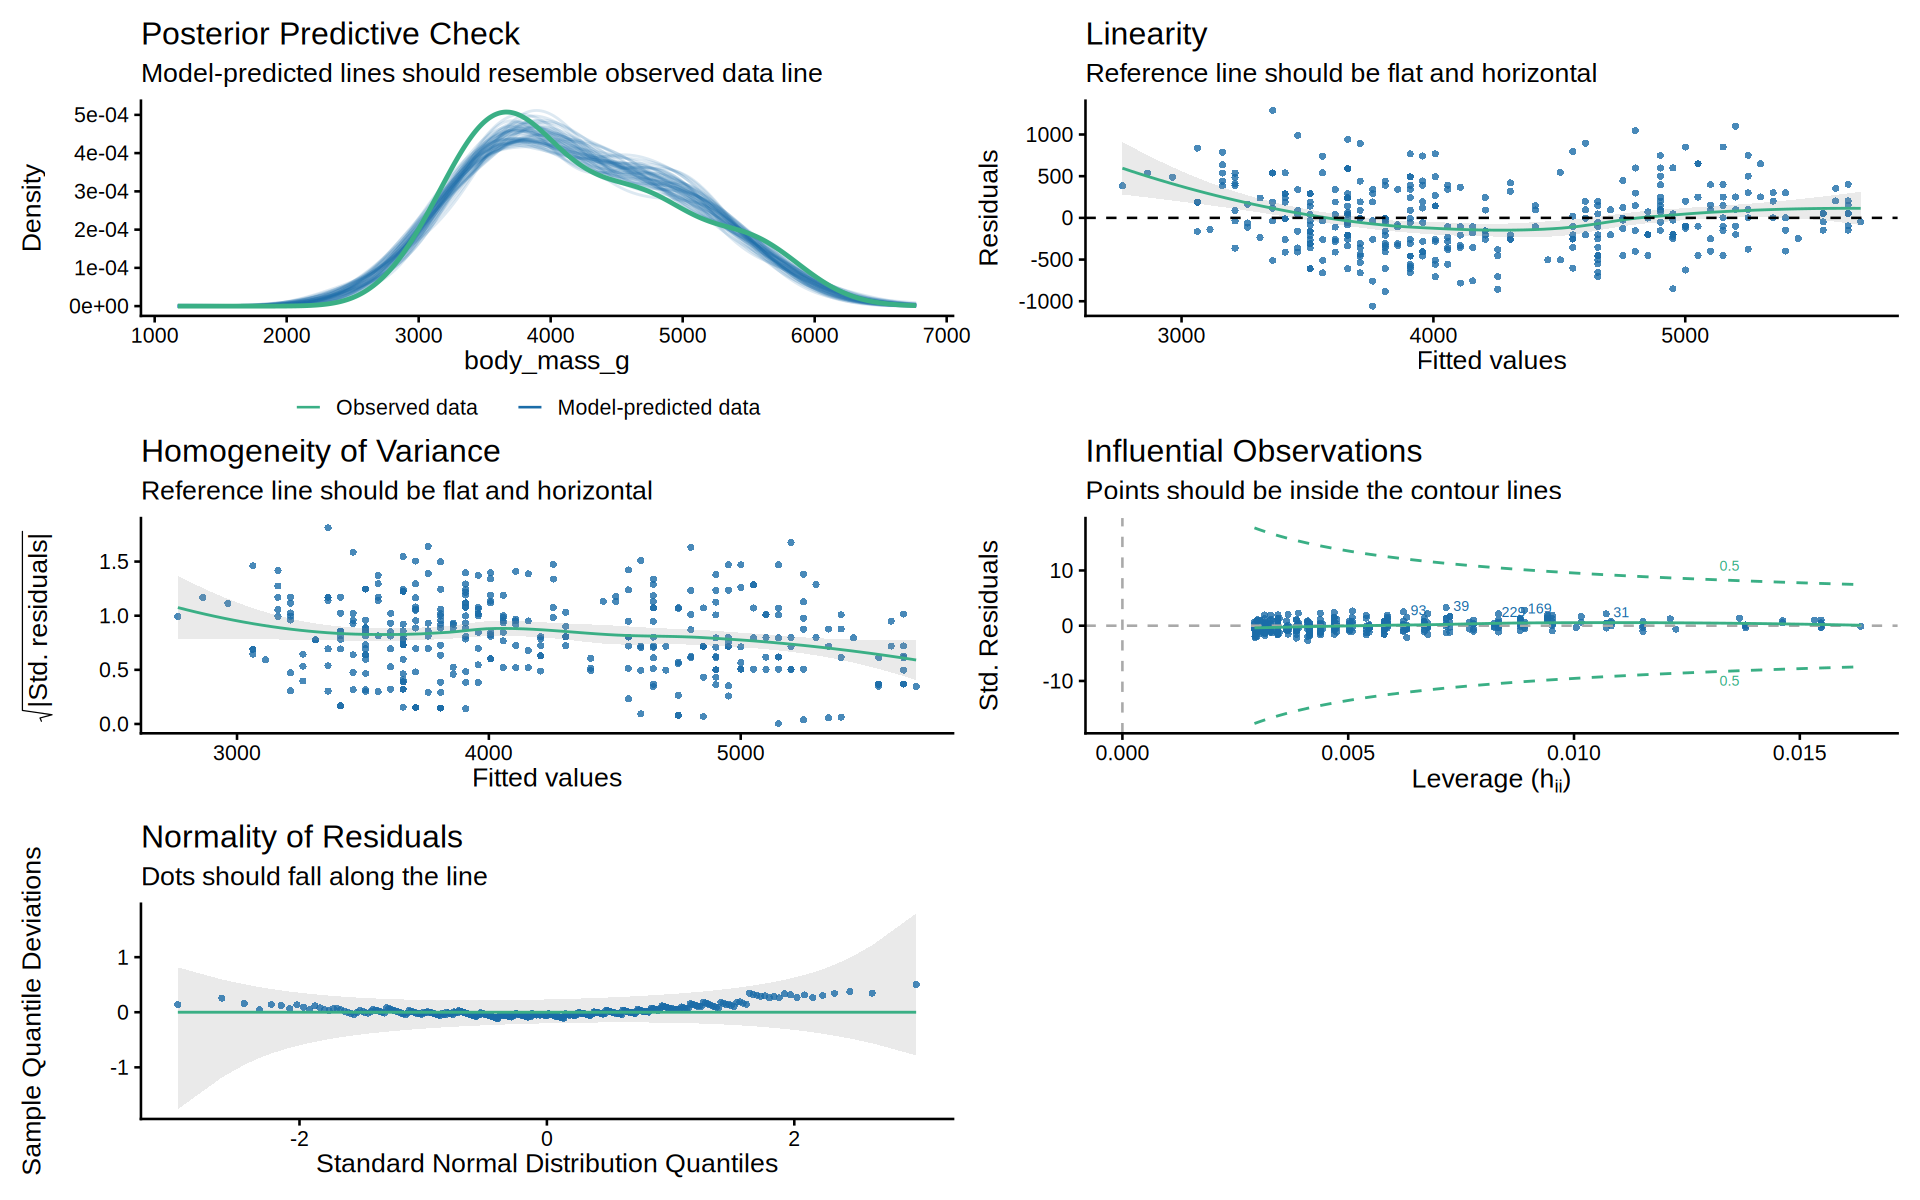

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 10)
plot(check_model(model), n_columns = 2, theme = theme_classic(base_size = 16))

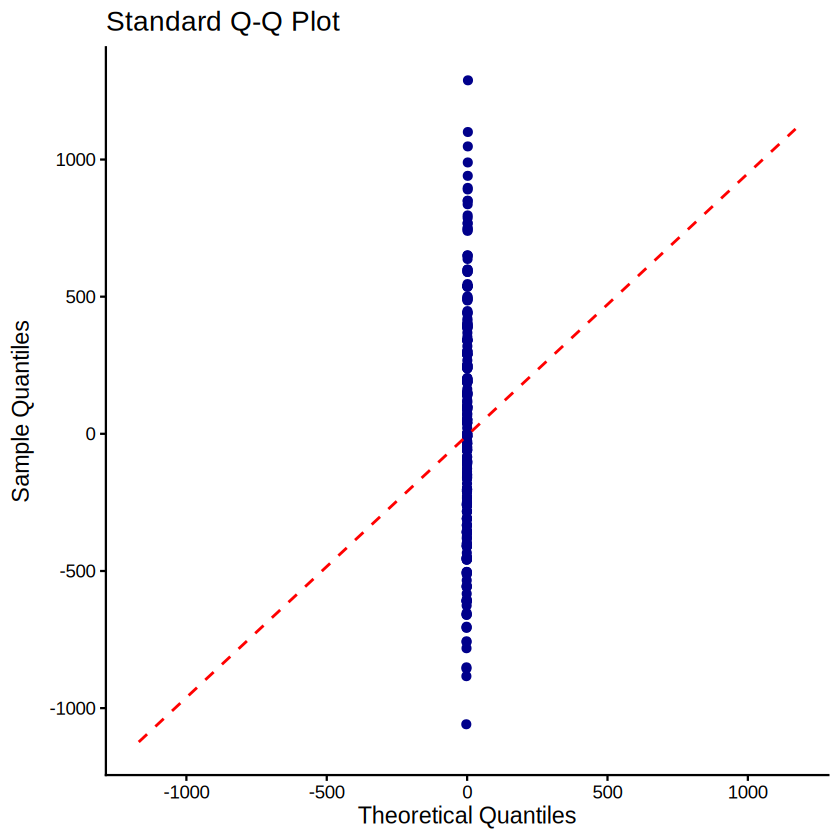

In [ ]:
# Fit a model and extract residuals
model <- lm(body_mass_g ~ flipper_length_mm, data = penguins)
res_data <- data.frame(residuals = residuals(model))

# Native ggplot2 Q-Q plot (no extra packages needed)
ggplot(res_data, aes(sample = residuals)) +
  stat_qq(color = "darkblue", size = 2) +
  stat_qq_line(color = "red", linetype = "dashed") +
  theme_classic(base_size = 14) +
  labs(
    title = "Standard Q-Q Plot",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  )

In [ ]:
# Install and load
#install.packages("parameters")
library(parameters)
#library(palmerpenguins)

# Fit a model
model <- lm(body_mass_g ~ flipper_length_mm + species, data = penguins)

# Extract clean parameters
model_parameters(model)

Parameter,Coefficient,SE,CI,CI_low,CI_high,t,df_error,p
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
(Intercept),-4031.4769,584.15134,0.95,-5180.50685,-2882.44693,-6.901425,338,2.551453e-11
flipper_length_mm,40.7054,3.07102,0.95,34.66468,46.74612,13.254686,338,1.401600e-32
speciesChinstrap,-206.5101,57.73065,0.95,-320.06672,-92.95352,-3.577132,338,3.980986e-04
speciesGentoo,266.8096,95.26374,0.95,79.42513,454.19408,2.800747,338,5.391808e-03


In [ ]:
library(performance)

# Get R-squared, AIC, RMSE, and other fit statistics
model_performance(model)

,AIC,AICc,BIC,R2,R2_adjusted,RMSE,Sigma
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,5031.523,5031.702,5050.697,0.7826479,0.7807187,373.3325,375.5351


In [ ]:
summary(model)


Call:
lm(formula = body_mass_g ~ flipper_length_mm + species, data = penguins)

Residuals:
    Min      1Q  Median      3Q     Max 
-927.70 -254.82  -23.92  241.16 1191.68 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       -4031.477    584.151  -6.901 2.55e-11 ***
flipper_length_mm    40.705      3.071  13.255  < 2e-16 ***
speciesChinstrap   -206.510     57.731  -3.577 0.000398 ***
speciesGentoo       266.810     95.264   2.801 0.005392 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 375.5 on 338 degrees of freedom
  (2 observations deleted due to missingness)
Multiple R-squared:  0.7826,	Adjusted R-squared:  0.7807 
F-statistic: 405.7 on 3 and 338 DF,  p-value: < 2.2e-16


In [ ]:
# Forces R to calculate a separate intercept for every species
model_no_intercept <- lm(body_mass_g ~ 0 + flipper_length_mm + species, data = penguins)
model_parameters(model_no_intercept)

Parameter,Coefficient,SE,CI,CI_low,CI_high,t,df_error,p
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
flipper_length_mm,40.7054,3.07102,0.95,34.66468,46.74612,13.254686,338,1.401600e-32
speciesAdelie,-4031.4769,584.15134,0.95,-5180.50685,-2882.44693,-6.901425,338,2.551453e-11
speciesChinstrap,-4237.9870,603.09976,0.95,-5424.28866,-3051.68536,-7.027008,338,1.169686e-11
speciesGentoo,-3764.6673,667.84449,0.95,-5078.32228,-2451.01229,-5.637042,338,3.652962e-08


In [ ]:
#| message: false
#| warning: false
install.packages("easystats")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘bayestestR’, ‘correlation’, ‘datawizard’, ‘effectsize’, ‘insight’, ‘modelbased’, ‘parameters’, ‘performance’, ‘report’, ‘see’




In [ ]:
library(tidyverse)
library(palmerpenguins)
library(performance)
library(see)

# Ensure clean data
df <- penguins %>% drop_na()

# 1. Define competing models
model1 <- lm(body_mass_g ~ flipper_length_mm, data = df)
model2 <- lm(body_mass_g ~ flipper_length_mm + species, data = df)
model3 <- lm(body_mass_g ~ flipper_length_mm + species + bill_length_mm, data = df)

# 2. Compare them all at once (and rank them automatically!)
comparison <- compare_performance(model1, model2, model3, rank = TRUE)

# 3. View as a clean table or markdown
comparison

Name,Model,R2,R2_adjusted,RMSE,Sigma,AIC_wt,AICc_wt,BIC_wt,Performance_Score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model3,lm,0.8243043,0.8221617,337.0077,339.5666,1.000000e+00,1.000000e+00,1.000000e+00,1.0000000
model2,lm,0.7870333,0.7850913,371.0352,373.2839,3.335124e-14,3.461151e-14,2.238926e-13,0.2210171
model1,lm,0.7620922,0.7613734,392.1603,393.3433,2.418503e-21,2.652517e-21,7.316942e-19,0.0000000


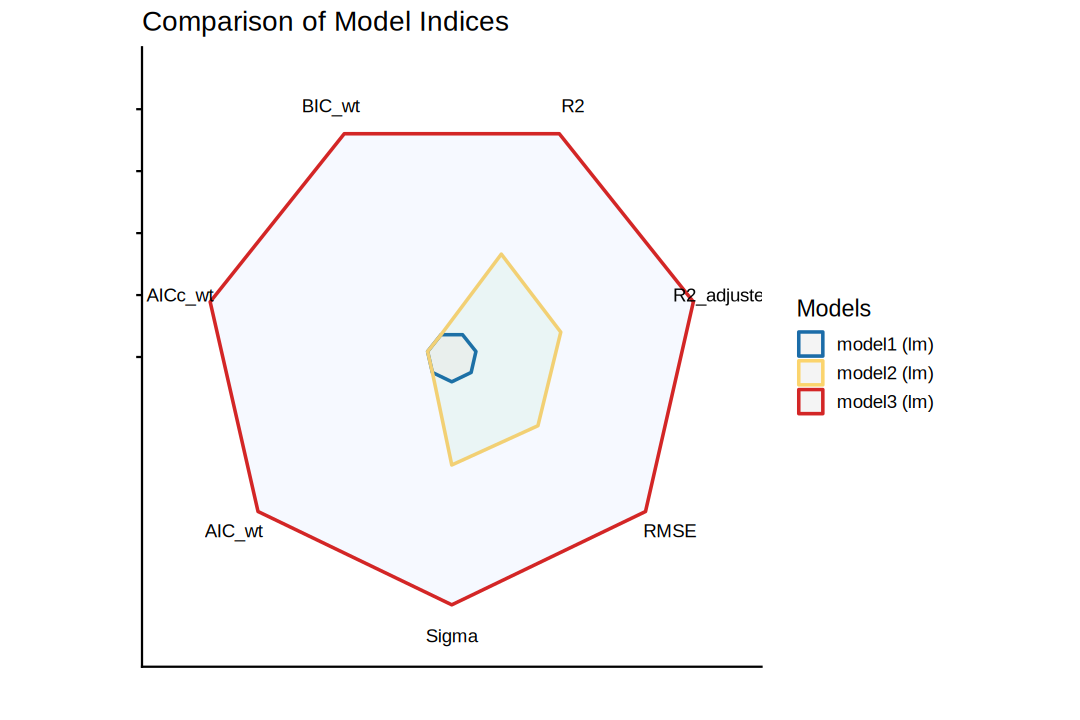

In [ ]:
# Set plot dimensions for Colab
options(repr.plot.width = 9, repr.plot.height = 6)

# Generate a visual comparison plot
plot(comparison) + theme_classic(base_size = 14)

In [ ]:
# Extract the exact coefficients for Model 3
model3 <- lm(body_mass_g ~ flipper_length_mm + species + bill_length_mm, data = df)
coef(model3)

(Intercept) flipper_length_mm  speciesChinstrap     speciesGentoo 
      -3864.07323          27.54429        -732.41667         113.25418 
   bill_length_mm 
         60.11732

In [ ]:
# Extract coefficients from your model
b <- coef(model3)

# Automatically print your equation text using base R
cat(sprintf(
  "Body Mass = %.2f + (%.2f * Flipper) + (%.2f * Bill) + (%.2f * Chinstrap) + (%.2f * Gentoo)\n",
  b["(Intercept)"],
  b["flipper_length_mm"],
  b["bill_length_mm"],
  b["speciesChinstrap"],
  b["speciesGentoo"]
))

Body Mass = -3864.07 + (27.54 * Flipper) + (60.12 * Bill) + (-732.42 * Chinstrap) + (113.25 * Gentoo)


In [ ]:
# Install (run once)
install.packages("equatiomatic")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘coda’, ‘furrr’, ‘broom.mixed’




In [36]:
library(equatiomatic)

# Fit Model 3
model3 <- lm(body_mass_g ~ flipper_length_mm + species + bill_length_mm, data = df)

# Generate the equation automatically!
eq <- extract_eq(model3, wrap = TRUE, terms_per_line = 2)
cat(as.character(eq))

ERROR: Error in model.frame.default(formula = body_mass_g ~ flipper_length_mm + : 'data' must be a data.frame, environment, or list


$$
\begin{aligned}
\operatorname{body\_mass\_g} &= \alpha + \beta_{1}(\operatorname{flipper\_length\_mm})\ + \\
&\quad \beta_{2}(\operatorname{species}_{\operatorname{Chinstrap}}) + \beta_{3}(\operatorname{species}_{\operatorname{Gentoo}})\ + \\
&\quad \beta_{4}(\operatorname{bill\_length\_mm}) + \epsilon
\end{aligned}
$$

In [ ]:
df_gentoo <- penguins %>%
  drop_na() %>%
  mutate(species = relevel(factor(species), ref = "Gentoo"))

# 2. Verify the new order of levels
print(levels(df_gentoo$species)) # Should output: "Gentoo" "Adelie" "Chinstrap"

# 3. Fit the model again using the same formula
model_gentoo <- lm(body_mass_g ~ flipper_length_mm + species + bill_length_mm, data = df_gentoo)

# 4. View the new coefficients
coef(model_gentoo)

[1] "Gentoo"    "Adelie"    "Chinstrap"


(Intercept) flipper_length_mm     speciesAdelie  speciesChinstrap 
      -3750.81906          27.54429        -113.25418        -845.67085 
   bill_length_mm 
         60.11732

In [ ]:
# 1. Relevel species so Chinstrap is Level 1
df_chinstrap <- penguins %>%
  drop_na() %>%
  mutate(species = relevel(factor(species), ref = "Chinstrap"))

# 2. Verify the new order of levels
print(levels(df_chinstrap$species)) # Should output: "Chinstrap" "Adelie" "Gentoo"

# 3. Fit the model and view coefficients
model_chinstrap <- lm(body_mass_g ~ flipper_length_mm + species + bill_length_mm, data = df_chinstrap)
coef(model_chinstrap)

[1] "Chinstrap" "Adelie"    "Gentoo"   


(Intercept) flipper_length_mm     speciesAdelie     speciesGentoo 
      -4596.48991          27.54429         732.41667         845.67085 
   bill_length_mm 
         60.11732

In [ ]:
install.packages("MuMIn")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘insight’




In [ ]:
if (!require("palmerpenguins")) install.packages("palmerpenguins")
if (!require("MuMIn")) install.packages("MuMIn")
library(tidyverse)
library(palmerpenguins)
library(MuMIn) # The gold standard package for AICc model selection

# 1. Prepare the data: Filter for Adelie and remove missing values in target/predictors
adelie_df <- penguins %>%
  filter(species == "Adelie") %>%
  drop_na(sex, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g) %>%
  mutate(sex = as.factor(sex)) # Ensure sex is binary factor

# 2. Fit the "Global Model" containing all candidate parameters
# Note: na.action = "na.fail" is strictly required for MuMIn to work
global_model <- glm(
  sex ~ bill_length_mm + bill_depth_mm + flipper_length_mm + body_mass_g,
  data = adelie_df,
  family = binomial(link = "logit"),
  na.action = "na.fail"
)

# 3. Generate Table 1: Dredge builds every possible combination of sub-models
# and ranks them automatically by AICc
model_table <- dredge(global_model, rank = "AICc")

# View the top models (equivalent to Table 1 in the paper)
print(model_table)

# 4. Generate Table 2: Model averaging and Relative Variable Importance (RWI)
# This calculates the cumulative Akaike weight for each predictor across all models
avg_model <- model.avg(model_table, subset = delta < 4) # usually delta < 2 or 4
summary(avg_model)

Loading required package: palmerpenguins

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘palmerpenguins’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: MuMIn


Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw


Fixed term is "(Intercept)"



Global model call: glm(formula = sex ~ bill_length_mm + bill_depth_mm + flipper_length_mm + 
    body_mass_g, family = binomial(link = "logit"), data = adelie_df, 
    na.action = "na.fail")
---
Model selection table 
        (Int) bll_dpt_mm bll_lng_mm bdy_mss_g flp_lng_mm df   logLik  AICc
8  -8.509e+01      1.306     0.8404  0.007790             4  -27.012  62.3
16 -7.918e+01      1.336     0.8403  0.007861  -0.035710  5  -26.839  64.1
7  -5.873e+01                0.7132  0.008486             3  -33.665  73.5
15 -5.751e+01                0.7130  0.008523  -0.007109  4  -33.657  75.6
6  -4.598e+01      1.065             0.007184             3  -38.075  82.3
14 -4.345e+01      1.077             0.007316  -0.017070  4  -38.009  84.3
5  -2.875e+01                        0.007814             2  -44.371  92.8
13 -2.857e+01                        0.007821  -0.001104  3  -44.371  94.9
4  -6.461e+01      1.828     0.8007                       3  -45.899  98.0
12 -7.044e+01      1.775     0.7


Call:
model.avg(object = model_table, subset = delta < 4)

Component model call: 
glm(formula = sex ~ <2 unique rhs>, family = binomial(link = "logit"), 
     data = adelie_df, na.action = na.fail)

Component models: 
     df logLik  AICc delta weight
123   4 -27.01 62.31   0.0   0.71
1234  5 -26.84 64.11   1.8   0.29

Term codes: 
    bill_depth_mm    bill_length_mm       body_mass_g flipper_length_mm 
                1                 2                 3                 4 

Model-averaged coefficients:  
(full average) 
                    Estimate Std. Error Adjusted SE z value Pr(>|z|)    
(Intercept)       -83.380334  18.584118   18.740928   4.449 8.60e-06 ***
bill_depth_mm       1.314667   0.426794    0.430467   3.054 0.002258 ** 
bill_length_mm      0.840368   0.237291    0.239335   3.511 0.000446 ***
body_mass_g         0.007810   0.001964    0.001981   3.943 8.03e-05 ***
flipper_length_mm  -0.010325   0.036570    0.036824   0.280 0.779176    
 
(conditional average) 
        

In [ ]:
install.packages("easystats")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘bayestestR’, ‘correlation’, ‘datawizard’, ‘effectsize’, ‘modelbased’, ‘parameters’, ‘performance’, ‘report’, ‘see’




In [ ]:
library(tidyverse)
library(palmerpenguins)
library(performance)

# 1. Prepare data for predicting sex
adelie_df <- penguins %>%
  filter(species == "Adelie") %>%
  drop_na(sex, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g)

# 2. Define your candidate models based on biological hypotheses
# Model A: Bill dimensions + Body Mass
model_a <- glm(sex ~ bill_length_mm + bill_depth_mm + body_mass_g,
               data = adelie_df, family = binomial)

# Model B: Bill length + Body Mass (simpler)
model_b <- glm(sex ~ bill_length_mm + body_mass_g,
               data = adelie_df, family = binomial)

# Model C: The "Global" model with everything
model_global <- glm(sex ~ bill_length_mm + bill_depth_mm + flipper_length_mm + body_mass_g,
                    data = adelie_df, family = binomial)

# 3. Compare them all at once using easystats
compare_performance(model_a, model_b, model_global, metrics = "AICc")

Name,Model,AICc,AICc_wt
<chr>,<chr>,<dbl>,<dbl>
model_a,glm,62.30747,0.708980296
model_b,glm,73.49996,0.002631568
model_global,glm,64.10651,0.288388136


In [ ]:
install.packages("janitor")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘snakecase’




In [ ]:
library(performance)

# 1. Capture the performance comparison object
comp <- compare_performance(model_a, model_b, model_global, metrics = "AICc")

# 2. View it and manually calculate Delta AICc (AICc - min(AICc))
# Extract the AICc column and compute delta
comp_df <- as.data.frame(comp)
comp_df$Delta_AICc <- comp_df$AICc - min(comp_df$AICc)

# 3. Print the results with Delta AICc
print(comp_df[, c("Name", "AICc", "Delta_AICc", "AICc_wt")])

          Name     AICc Delta_AICc     AICc_wt
1      model_a 62.30747   0.000000 0.708980296
2      model_b 73.49996  11.192496 0.002631568
3 model_global 64.10651   1.799041 0.288388136


In [ ]:
library(tidyverse)
library(palmerpenguins)
library(janitor)
library(MuMIn) # Required for automated multi-model comparison

# 1. Prepare and clean the raw Adelie data
adelie_raw <- penguins_raw %>%
  clean_names() %>%
  filter(str_detect(species, "Adelie")) %>%
  select(sex, culmen_length_mm, culmen_depth_mm, flipper_length_mm, body_mass_g) %>%
  drop_na() %>%
  mutate(sex = as.factor(tolower(sex)))

# 2. Fit the global model (na.action = "na.fail" is mandatory for MuMIn)
global_model <- glm(
  sex ~ culmen_length_mm + culmen_depth_mm + flipper_length_mm + body_mass_g,
  data = adelie_raw,
  family = binomial,
  na.action = "na.fail"
)

# 3. Generate all model combinations ranked by AICc
# This automatically anchors the top model's Delta AICc at 0.00
table_results <- dredge(global_model, rank = "AICc")

# View the top models
print(table_results)

Fixed term is "(Intercept)"



Global model call: glm(formula = sex ~ culmen_length_mm + culmen_depth_mm + flipper_length_mm + 
    body_mass_g, family = binomial, data = adelie_raw, na.action = "na.fail")
---
Model selection table 
        (Int) bdy_mss_g clm_dpt_mm clm_lng_mm flp_lng_mm df   logLik  AICc
8  -8.509e+01  0.007790      1.306     0.8404             4  -27.012  62.3
16 -7.918e+01  0.007861      1.336     0.8403  -0.035710  5  -26.839  64.1
6  -5.873e+01  0.008486                0.7132             3  -33.665  73.5
14 -5.751e+01  0.008523                0.7130  -0.007109  4  -33.657  75.6
4  -4.598e+01  0.007184      1.065                        3  -38.075  82.3
12 -4.345e+01  0.007316      1.077             -0.017070  4  -38.009  84.3
2  -2.875e+01  0.007814                                   2  -44.371  92.8
10 -2.857e+01  0.007821                        -0.001104  3  -44.371  94.9
7  -6.461e+01                1.828     0.8007             3  -45.899  98.0
15 -7.044e+01                1.775     0.7767   

In [ ]:
library(tidyverse)
library(palmerpenguins)
library(janitor)
library(performance)

# 1. Filter penguins_raw for Adelie and the study's exact seasons
adelie_study <- penguins_raw %>%
  clean_names() %>%
  filter(str_detect(species, "Adelie"),
         study_name %in% c("PAL0708", "PAL0809", "PAL0910")) %>%
  select(sex, culmen_length_mm, culmen_depth_mm, flipper_length_mm, body_mass_g) %>%
  drop_na() %>%
  mutate(sex = as.factor(tolower(sex)))

# 2. Define the three specific candidate models
model_a <- glm(sex ~ culmen_length_mm + culmen_depth_mm + body_mass_g,
               data = adelie_study, family = binomial)

model_b <- glm(sex ~ culmen_length_mm + body_mass_g,
               data = adelie_study, family = binomial)

model_global <- glm(sex ~ culmen_length_mm + culmen_depth_mm + flipper_length_mm + body_mass_g,
                    data = adelie_study, family = binomial)

# 3. Compare performance using easystats and calculate Delta AICc
comp <- compare_performance(model_a, model_b, model_global, metrics = "AICc")
comp_df <- as.data.frame(comp)
comp_df$Delta_AICc <- comp_df$AICc - min(comp_df$AICc)

# Print the final clean comparison table
print(comp_df[, c("Name", "AICc", "Delta_AICc", "AICc_wt")])

          Name     AICc Delta_AICc     AICc_wt
1      model_a 62.30747   0.000000 0.708980296
2      model_b 73.49996  11.192496 0.002631568
3 model_global 64.10651   1.799041 0.288388136


In [ ]:
library(tidyverse)
library(palmerpenguins)
library(performance)

# 1. Prepare data
adelie_df <- penguins %>%
  filter(species == "Adelie") %>%
  select(sex, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g) %>%
  drop_na() %>%
  mutate(sex = as.factor(sex))

# 2. Fit models
model_a <- glm(sex ~ bill_length_mm + bill_depth_mm + body_mass_g,
               data = adelie_df, family = binomial)
model_b <- glm(sex ~ bill_length_mm + body_mass_g,
               data = adelie_df, family = binomial)
model_global <- glm(sex ~ bill_length_mm + bill_depth_mm + flipper_length_mm + body_mass_g,
                    data = adelie_df, family = binomial)

# 3. Get AICc and weights via easystats performance
comp <- compare_performance(model_a, model_b, model_global, metrics = "AICc")
summary_df <- as.data.frame(comp) %>%
  mutate(Delta_AICc = AICc - min(AICc)) %>%
  select(Name, AICc, Delta_AICc, AICc_wt)

# 4. Robust metric extractor using base R model properties
extract_metrics <- function(mod, data) {
  # McFadden's R2 via deviance ratio (bulletproof for glm binomial)
  r2_mf <- 1 - (mod$deviance / mod$null.deviance)

  # Classification accuracy using a 0.5 probability threshold
  preds <- predict(mod, type = "response")
  pred_class <- ifelse(preds > 0.5, levels(data$sex)[2], levels(data$sex)[1])
  accuracy <- mean(pred_class == data$sex) * 100

  tibble(
    r2_mf = r2_mf,
    percent_correct = accuracy
  )
}

# 5. Bind metrics cleanly by model name
models_list <- list(model_a = model_a, model_b = model_b, model_global = model_global)
extra_metrics_df <- map_dfr(models_list, extract_metrics, data = adelie_df, .id = "Model_Key")

# 6. Merge into final clean summary table
final_table <- summary_df %>%
  mutate(Model_Key = c("model_a", "model_b", "model_global")) %>%
  left_join(extra_metrics_df, by = "Model_Key") %>%
  select(-Model_Key)

print(final_table)

          Name     AICc Delta_AICc     AICc_wt     r2_mf percent_correct
1      model_a 62.30747   0.000000 0.708980296 0.7330827        91.78082
2      model_b 73.49996  11.192496 0.002631568 0.6673355        89.72603
3 model_global 64.10651   1.799041 0.288388136 0.7347915        93.15068
